In [6]:
import argparse
import wave
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample_poly

In [7]:
raw = np.fromfile('example_iq/cc1101_test1.cu8', dtype=np.uint8)
raw = raw[: len(raw) // 2*2]
iq = raw.reshape(-1, 2)
sample_rate = 2_040_000

i = (iq[:, 0].astype(np.float32) - 127.5) / 127.5 
q = (iq[:, 1].astype(np.float32) - 127.5) / 127.5
iq = i + 1j*q

In [8]:
iq

array([-0.00392157+0.00392157j,  0.00392157-0.00392157j,
       -0.00392157-0.00392157j, ...,  0.00392157+0.01176471j,
       -0.00392157+0.00392157j,  0.00392157+0.00392157j],
      shape=(40800000,), dtype=complex64)

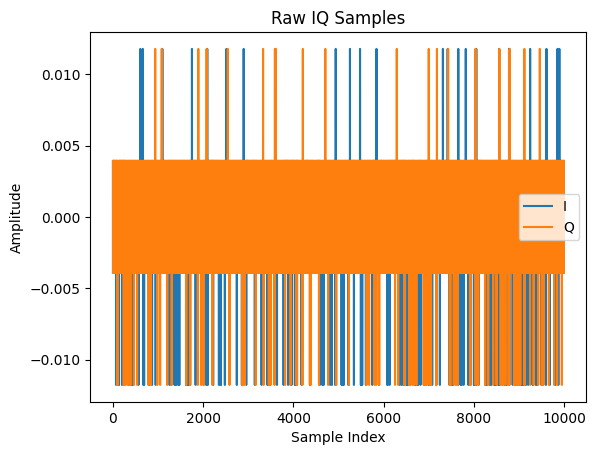

In [9]:

plt.plot(iq.real[:10000], label='I')
plt.plot(iq.imag[:10000], label='Q')
plt.title('Raw IQ Samples')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

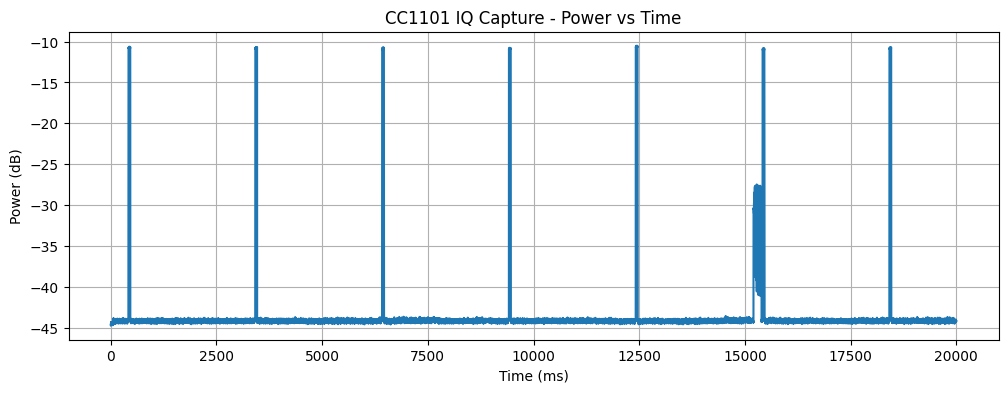

In [12]:
power = np.abs(iq)**2
window = sample_rate // 1000
trimmed = power[: len(power) // window * window]
power_ms = trimmed.reshape(-1, window).mean(axis=1)

time_ms = np.arange(len(power_ms))

power_ms_db = 10 * np.log10(power_ms + 1e-12)

plt.figure(figsize=(12, 4))
plt.plot(time_ms, power_ms_db)
plt.xlabel("Time (ms)")
plt.ylabel("Power (dB)")
plt.title("CC1101 IQ Capture - Power vs Time")
plt.grid(True)
plt.show()

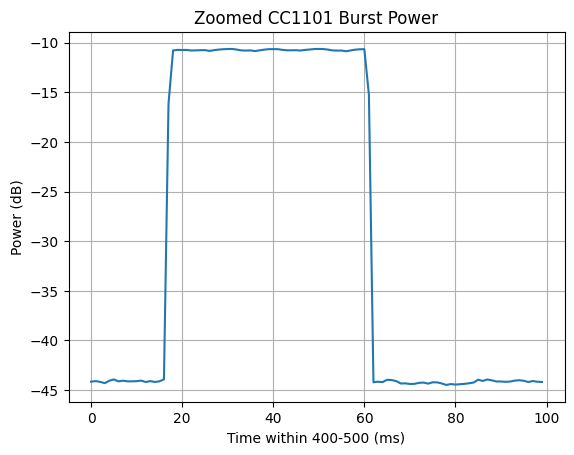

In [17]:
plt.plot(power_ms_db[400:500])
plt.xlabel("Time within 400-500 (ms)")
plt.ylabel("Power (dB)")
plt.title("Zoomed CC1101 Burst Power")
plt.grid(True)
plt.show()

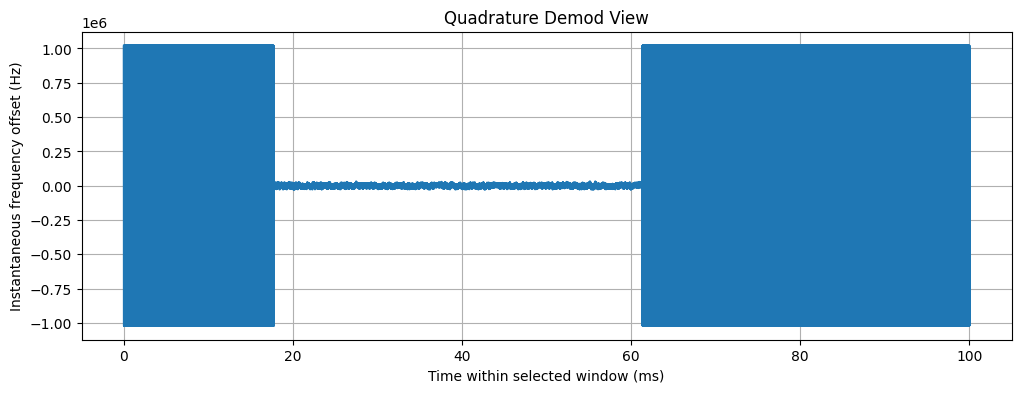

In [19]:
start_s = 0.400
end_s = 0.500

segment = iq[int(start_s * sample_rate):int(end_s * sample_rate)]

phase = np.unwrap(np.angle(segment))
freq = np.diff(phase) * sample_rate / (2 * np.pi)

t_ms = np.arange(len(freq)) / sample_rate * 1000

plt.figure(figsize=(12, 4))
plt.plot(t_ms, freq)
plt.xlabel("Time within selected window (ms)")
plt.ylabel("Instantaneous frequency offset (Hz)")
plt.title("Quadrature Demod View")
plt.grid(True)
plt.show()

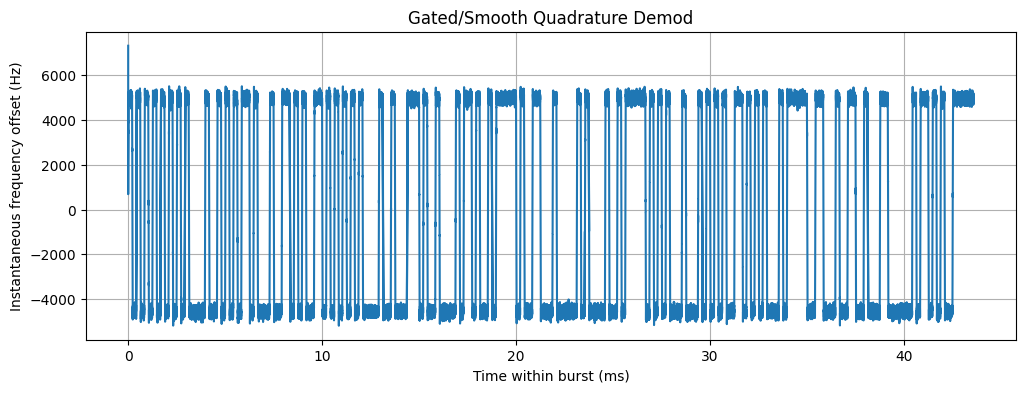

In [20]:
start_s = 0.400
end_s = 0.500

segment = iq[int(start_s * sample_rate):int(end_s * sample_rate)]
power = np.abs(segment) ** 2
power_db = 10 * np.log10(power + 1e-12)

# crude threshold: keep only strong burst region
threshold_db = -25
mask = power_db > threshold_db

idx = np.where(mask)[0]
burst = segment[idx[0]:idx[-1]]

phase = np.unwrap(np.angle(burst))
freq = np.diff(phase) * sample_rate / (2 * np.pi)

# smooth it so the FSK levels are easier to see
smooth_n = 64
freq_smooth = np.convolve(freq, np.ones(smooth_n) / smooth_n, mode="valid")

t_ms = np.arange(len(freq_smooth)) / sample_rate * 1000

plt.figure(figsize=(12, 4))
plt.plot(t_ms, freq_smooth)
plt.xlabel("Time within burst (ms)")
plt.ylabel("Instantaneous frequency offset (Hz)")
plt.title("Gated/Smooth Quadrature Demod")
plt.grid(True)
plt.show()

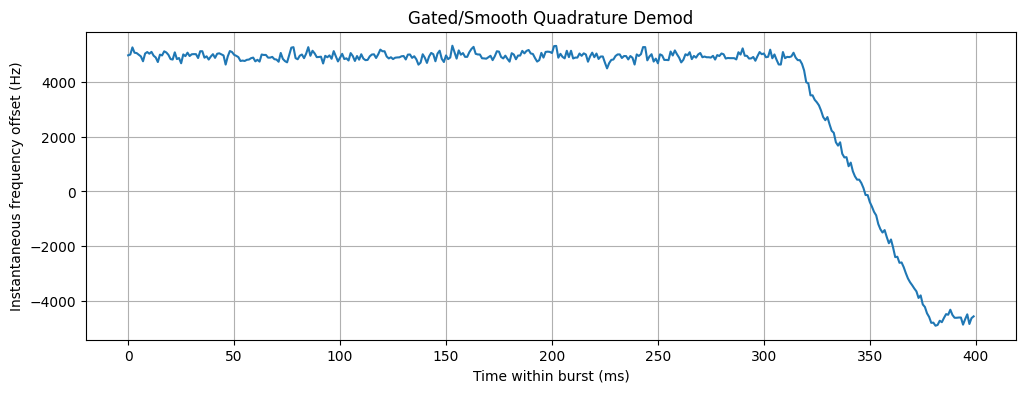

In [27]:
plt.figure(figsize=(12, 4))
plt.plot(freq_smooth[100:500])
plt.xlabel("Time within burst (ms)")
plt.ylabel("Instantaneous frequency offset (Hz)")
plt.title("Gated/Smooth Quadrature Demod")
plt.grid(True)
plt.show()